### Abrertura do arquivo

In [27]:
file = open('./lista_especies.txt', 'r')

Utilizei a função `open(<caminho_arquivo>, <modo>)`:
 - `<caminho_arquivo>` -> .\lista_especies.txt, onde .\ define que é na pasta atual (uma vez que o arquivo de solução e a lista estão na mesma pasta) e seguido pelo nome
 - `<modo>` ->  `r` (read) para leitura, outras opções possíveis são `w` (write) para alteração e `a` (append) para acrescer ao fim do arquivo entre outras

### Dicionário de especies e leitura de arquivo

In [28]:
species = {}

while True:
	line = file.readline().strip()
	if not line:
		break	

	if not line in species:
		species[line] = 1
	else:
		species[line] += 1


- Declarei o dicionário `species = {}`

- Utilizei do método da classe File para ler as linhas (`readline()`), que é delimitada pelo caracter de controle `\n`, por isso o `strip()`, método que remove o mesmo

- Existem várias abordagens para percorrer um arquivo, adotei o uso de um laço infinito `while True:`, foi preciso de uma verificação durante o laço (`if not line:` verifica se a linha está vazia) para quebrar (`break`) o mesmo.

- Por fim para contar as ocorrências, verifiquei se a linha (espécie na lista) esta dentro do dicionário de espécies, caso não esteja adiciono a especie com o valor 1, caso esteja acrescento em 1 a espécie.

### Exibição da riqueza de espécies

In [29]:
print(f"A riqueza é de {len(species.keys())} espécies")

A riqueza é de 20 espécies


- Utilizei o método `keys()` para ter o retorno de uma lista das entradas do dicionário, por ser uma lista a função `len()` retorna a quantidade de ocorrências

### Exibição da abundância de espécies

In [30]:
def _print(str, asBold):
	if(asBold):
		print(f"{"\033[1m"}{str}{"\033[0m"}")
		return
	print(str)

orderedSpecies = sorted(species.items(), key=lambda x: x[1], reverse=True)

_print("Abundância das espécies (ordem decrescente):",True)
for i, value in enumerate(orderedSpecies):	
	_print(f"  {i + 1}º {value[0]} --> {value[1]}",not i)

Abundância das espécies (ordem decrescente):
  1º Cephalotes pusillus --> 7
  2º Cephalotes ustus --> 5
  3º Ectatomma tuberculatum --> 4
  4º Camponotus renggeri --> 4
  5º Camponotus rufipes --> 4
  6º Cephalotes depressus --> 3
  7º Pachycondyla harpax --> 3
  8º Ectatomma brunneum --> 3
  9º Cephalotes atratus --> 3
  10º Basiceros scambognathus --> 3
  11º Solenopsisis geminata --> 1
  12º Solenopsis tridens --> 1
  13º Solenopsis sulfurea --> 1
  14º Solenopsis substituta --> 1
  15º Solenopsis pollux --> 1
  16º Solenopsis geminata --> 1
  17º Solenopsis brevicornis --> 1
  18º Solenopsis basalis --> 1
  19º Smithistruma epinotalis --> 1
  20º Strumigenys elongata --> 1


- Defini uma função _print apenas para facilitar o uso do bold
- Utilizei da função `sorted(<items>, <função_de_extração>... reverse=<bool>)` para ordenar de ordem decrescente os valores do dicionário
	- `<items>`: Items a serem ordenados
	- `<função_de_extração>`: Funções lambda, são funções não nomeadas que não dependem de ser definidas (`def`). No caso `x: x[1]` esta definindo que a extração do valor é por meio do segundo valor do vetor `x` que por sua vez é extraído da iteração do vetor `<items>`.
	- `<reverse>`: apenas define que ordenação deve ser decrescente
- Por fim, utilizei a função `_print` para printar uma mensagem destacada e depois percorri as entradas que foram ordenadas e atribuídas a variável `orderedSpecies` por meio de um laço `for` na enumeração dos valores para capturar o índice. Como os valores estão ordenados utilizo o `not i` (como 0 é falso `\b00000000` e qualquer outro número é verdadeiro a negação de `i` retorna `True` quando 0 e `False` quando diferente de 0) para poder defnir `asBold` sendo verdadeiro no primeiro valor (de maior abundância)

### Gráficos

In [31]:
import matplotlib.pyplot as plot

labels = list(species.keys())
values = list(species.values())

- Importei a `matplot.pyplot` como `plot`
- Defini labels e values por meio do dicionário de espécies

#### [Barras](https://matplotlib.org/stable/plot_types/basic/bar.html)

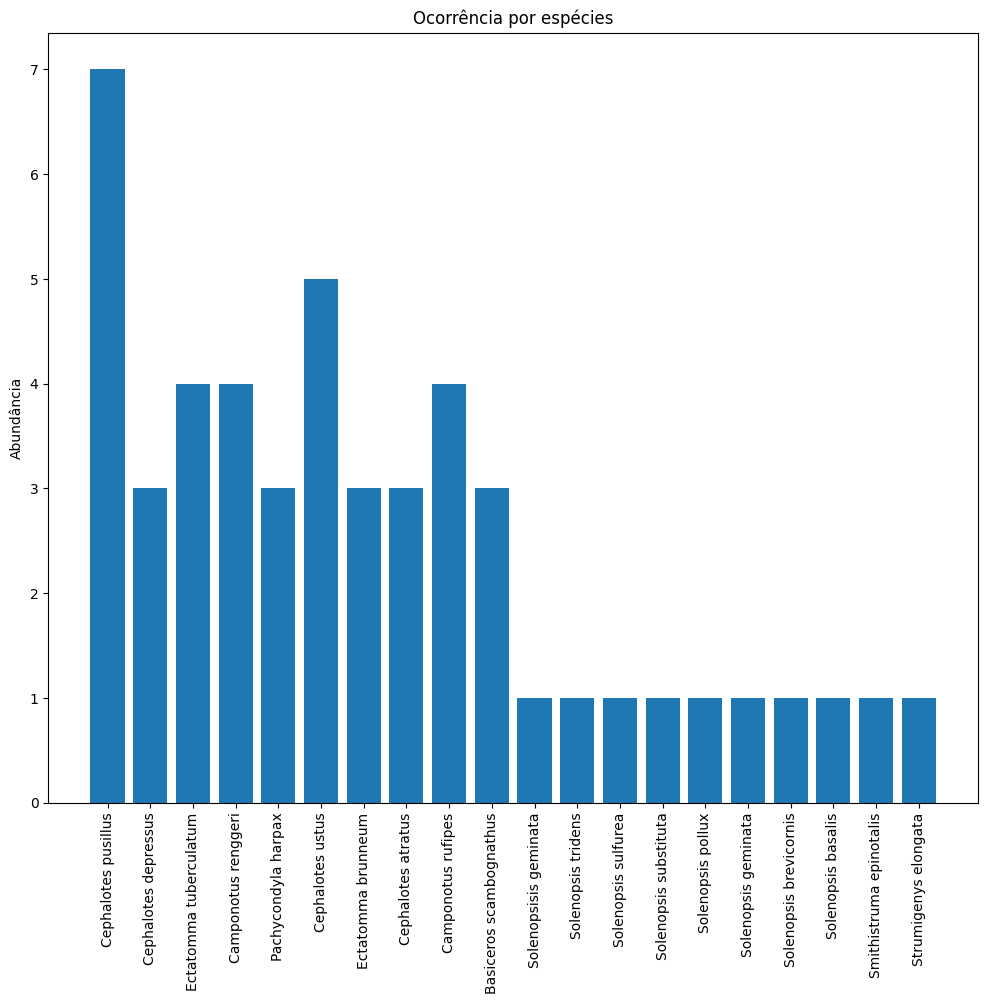

In [32]:
plot.figure(figsize=(12,10))

plot.bar(labels,values)
plot.title("Ocorrência por espécies")
plot.ylabel("Abundância")
plot.xticks(rotation=90)
plot.show()

#### [Setores](https://matplotlib.org/stable/plot_types/stats/pie.html)

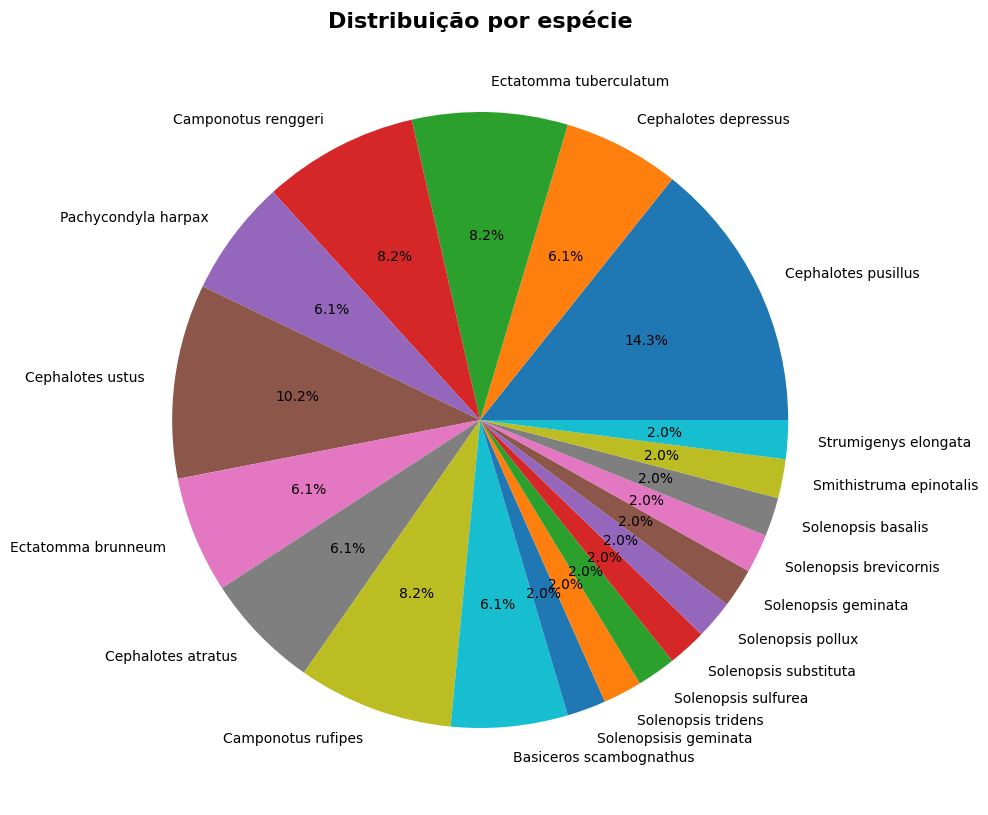

In [33]:
plot.figure(figsize=(12, 10))

plot.pie(
	values, 
  labels=labels,
  autopct='%1.1f%%',
  textprops={'fontsize': 10}	
)
plot.title("Distribuição por espécie", fontsize=16, fontweight='bold')
plot.show()

#### [Boxplot](https://matplotlib.org/stable/plot_types/stats/boxplot_plot.html)

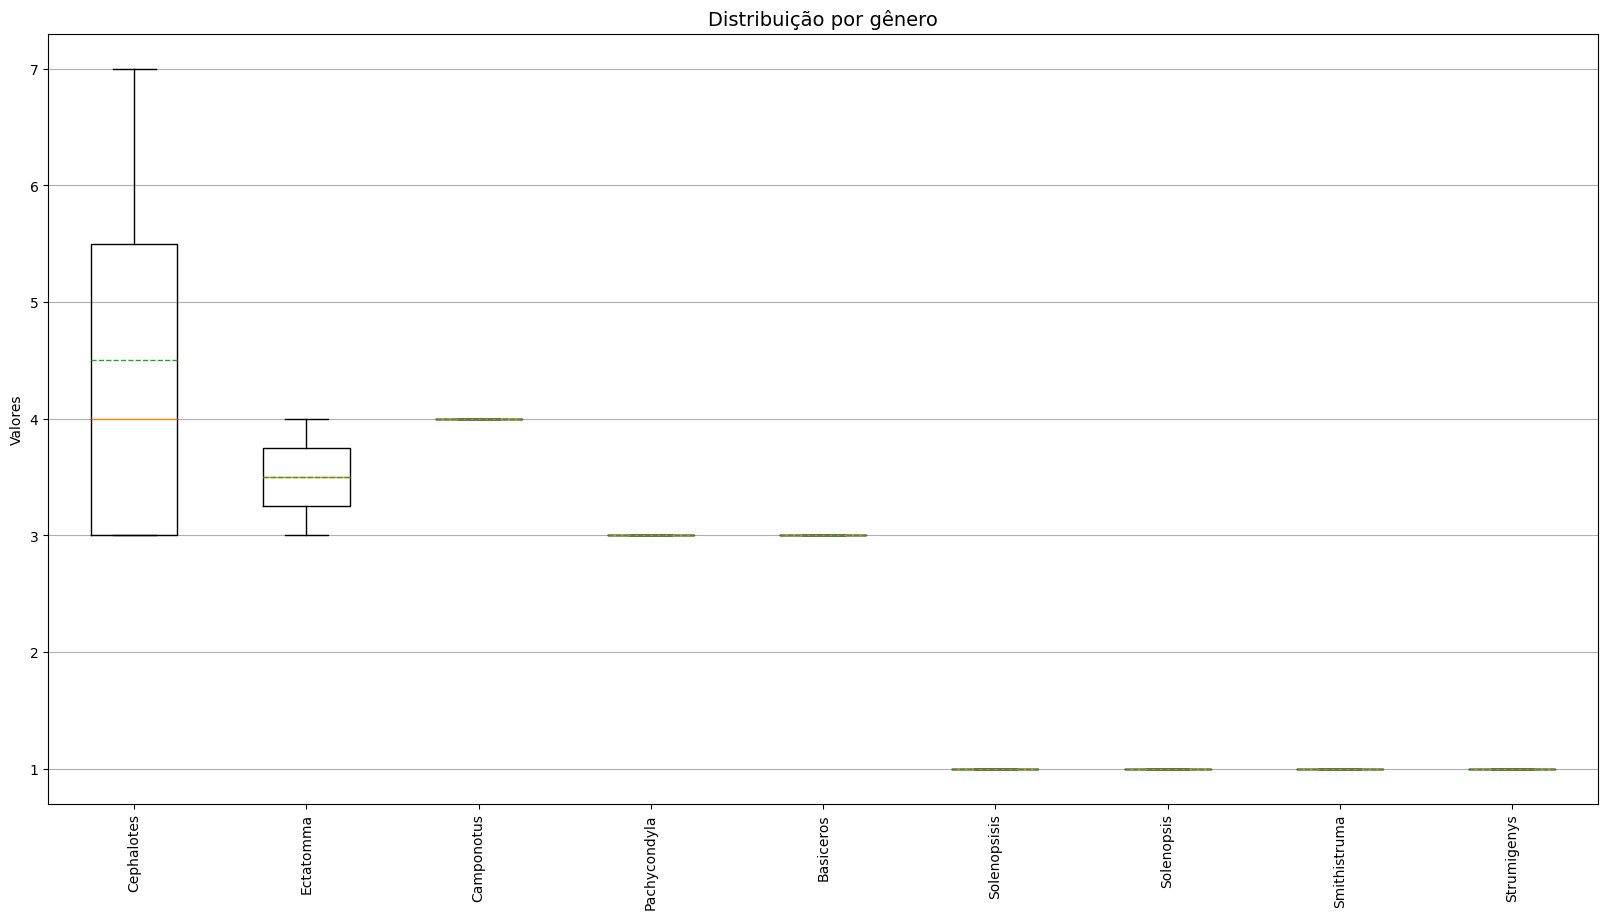

In [34]:
genders = {}
for specie in species:
	gender = specie.split(" ")[0]
	if not gender in genders:
		genders[gender] = []	
	genders[gender].append(species[specie])

genderLabels = list(genders.keys())
genderValues = list(genders.values())

plot.figure(figsize=(20, 10))

plot.boxplot(
	genderValues,
	tick_labels=genderLabels,
	showmeans=True,
	meanline=True
)
plot.title("Distribuição por gênero", fontsize=14)
plot.ylabel("Valores")
plot.xticks(rotation=90)
plot.grid(axis='y', alpha=1)
plot.show()